<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> AI For Leaders - 2 <br>
<b>Semester:</b> Spring 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

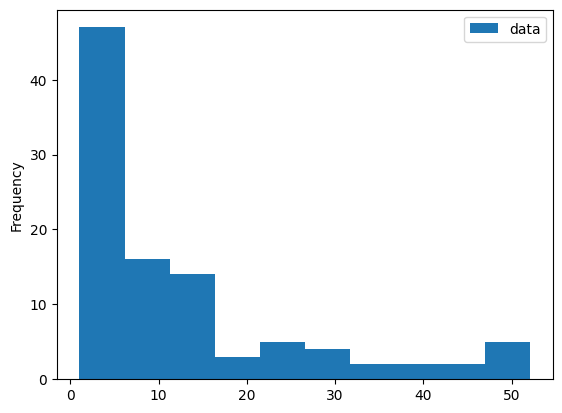

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

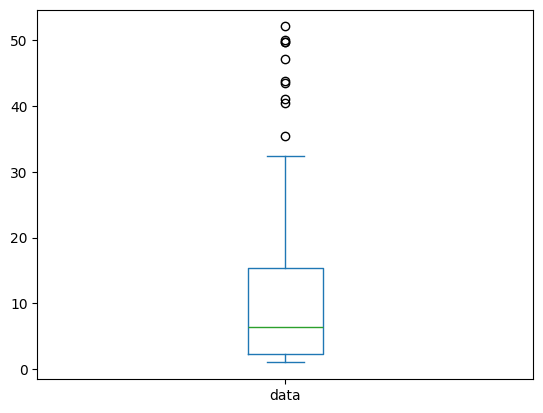

In [3]:
df.plot.box()

### Answer:

- **Histogram** 
    - **Pros**
        - Shows the <u>shape of the distribution</u> and clearly reveals <u>right skewness</u>
        - Displays <u>frequency concentration</u>
        - Makes it possible to identify if the data follow a unimodal, bimodal, or multimodal pattern
        - Helps identify the number of drugs that fall into <u>more expensive price categories</u>

    - **Cons**
        - Does not explicitly show summary statistics (median, quartiles)
        - Interpretation depends on bin width selection
        - Harder to read exact percentile values (e.g., 75th percentile)
        - Extreme values can stretch the x-axis and compress most data

- **Boxplot** 
    - **Pros**
        - Clearly shows:
            - Median
            - 25th and 75th percentiles (IQR)
            - Potential outliers

        - It seems to be a good option for answering the question: "How much do the more expensive drugs tend to cost relative to the others?"
        - More compact and less sensitive to formatting choices

    - **Cons**
        - Does not show detailed distribution shape
        - Hides modality and frequency concentration
        - Less intuitive for non-technical audiences


- **Which Visualization Technique Would I Choose?**
    - I would choose the **boxplot** 
    - The histogram is better for understanding distribution shape, but <u>the boxplot is more aligned with the administrator’s question:</u>
        - ***“How much do the more expensive drugs tend to cost, in the context of the other prices?”***
    - The boxplot directly communicates:
        - Where the top 25% begins (75th percentile)
        - Spread of expensive drugs (How far prices extend above the 75th percentile)
        - Whether there are extreme high-cost outliers

- **How I Would Improve the Formatting?**
    - **For the Histogram:**
        - Increase number of bins for smoother shape
        - Add vertical line at the 75th percentile
        - Add axis labels and title

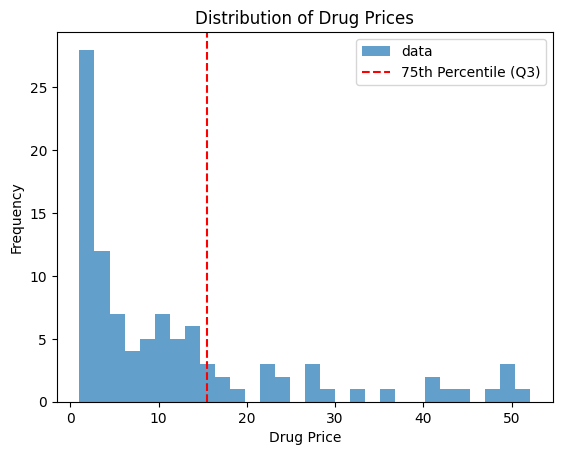

In [ ]:
import matplotlib.pyplot as plt

df.plot.hist(bins=30, alpha=0.7)
plt.axvline(df.quantile(0.75).values[0], color='red', linestyle='--', label='75th Percentile (Q3)')
plt.xlabel("Drug Price")
plt.title("Distribution of Drug Prices")
plt.legend()

-    
    - **For the Boxplot:**
        - We can add horizontal orientation for readability
        - Improve title label

Text(0.5, 1.0, 'Boxplot of Drug Prices')

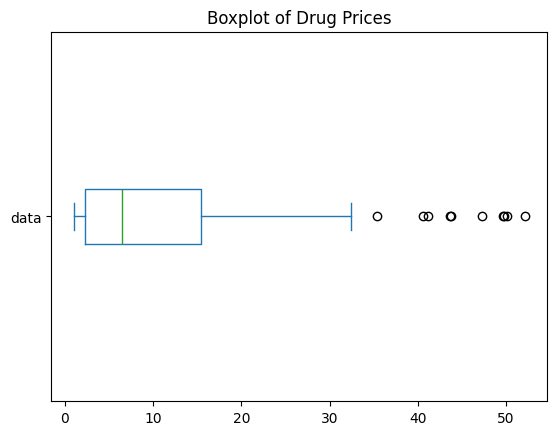

In [22]:
df.plot.box(vert=False)
plt.title("Boxplot of Drug Prices")

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

### Answer:

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### *1- Load the dataset & quick preview*

In [24]:
path = "data/diabetes_012_health_indicators_BRFSS2015.csv"
df_cdc_diabetes = pd.read_csv(path)

print("Shape (rows, cols):", df_cdc_diabetes.shape)
display(df_cdc_diabetes.head())

Shape (rows, cols): (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


#### *2- Data audit*

In [25]:
audit = pd.DataFrame({
    "dtype": df_cdc_diabetes.dtypes.astype(str),
    "n_unique": df_cdc_diabetes.nunique(),
    "n_missing": df_cdc_diabetes.isna().sum()
}).sort_values(["n_missing", "n_unique"], ascending=[False, True])

print("Total missing values:", int(df_cdc_diabetes.isna().sum().sum()))
display(audit)

Total missing values: 0


,dtype,n_unique,n_missing
HighBP,float64,2,0
HighChol,float64,2,0
CholCheck,float64,2,0
Smoker,float64,2,0
Stroke,float64,2,0
HeartDiseaseorAttack,float64,2,0
PhysActivity,float64,2,0
Fruits,float64,2,0
Veggies,float64,2,0
HvyAlcoholConsump,float64,2,0


- No missing values (great for usability)
- Many columns are binary (0/1) or ordinal-coded (Age 1–13, GenHlth 1–5, Income 1–8, Education 1–6)
- Features [BMI, MentHlth, PhysHlth]: continuous / high-cardinality numeric columns

#### *3- Categorical/Ordinal Columns Vs Continuous Columns*

In [27]:
n_unique = df_cdc_diabetes.nunique()
categorical_cols = n_unique[n_unique <= 13].index.tolist()   # binary + ordinal
continuous_cols  = n_unique[n_unique > 13].index.tolist()    # BMI, MentHlth, PhysHlth

print("Categorical/ordinal:", categorical_cols)
print("Continuous-ish:", continuous_cols)

Categorical/ordinal: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Continuous-ish: ['BMI', 'MentHlth', 'PhysHlth']


- Categorical/ordinal: most columns (including Diabetes status (target), Age codes, Income codes…)
- Continuous-ish: ['BMI', 'MentHlth', 'PhysHlth']

#### *4- Means, Medians, Modes, Min/Max*

In [28]:
summary = df_cdc_diabetes.describe().T[["mean", "50%", "min", "max"]].rename(columns={"50%": "median"})
summary["mode"] = df_cdc_diabetes.mode(dropna=True).iloc[0]
display(summary.sort_index())

,mean,median,min,max,mode
Age,8.032119,8.0,1.0,13.0,9.0
AnyHealthcare,0.951053,1.0,0.0,1.0,1.0
BMI,28.382364,27.0,12.0,98.0,27.0
CholCheck,0.962670,1.0,0.0,1.0,1.0
Diabetes_012,0.296921,0.0,0.0,2.0,0.0
DiffWalk,0.168224,0.0,0.0,1.0,0.0
Education,5.050434,5.0,1.0,6.0,6.0
Fruits,0.634256,1.0,0.0,1.0,1.0
GenHlth,2.511392,2.0,1.0,5.0,2.0
HeartDiseaseorAttack,0.094186,0.0,0.0,1.0,0.0


- **Important highlights:**
    - **BMI**: mean ≈ 28.38, median=27, min=12, max=98
    - **MentHlth**: mean ≈ 3.18, median=0, mode=0
    - **PhysHlth**: mean ≈ 4.24, median=0, mode=0

=> **Ment/Phys health** are <u>zero-inflated (lots of 0s)</u>

#### *5- Bar plots for categorical/ordinal columns*

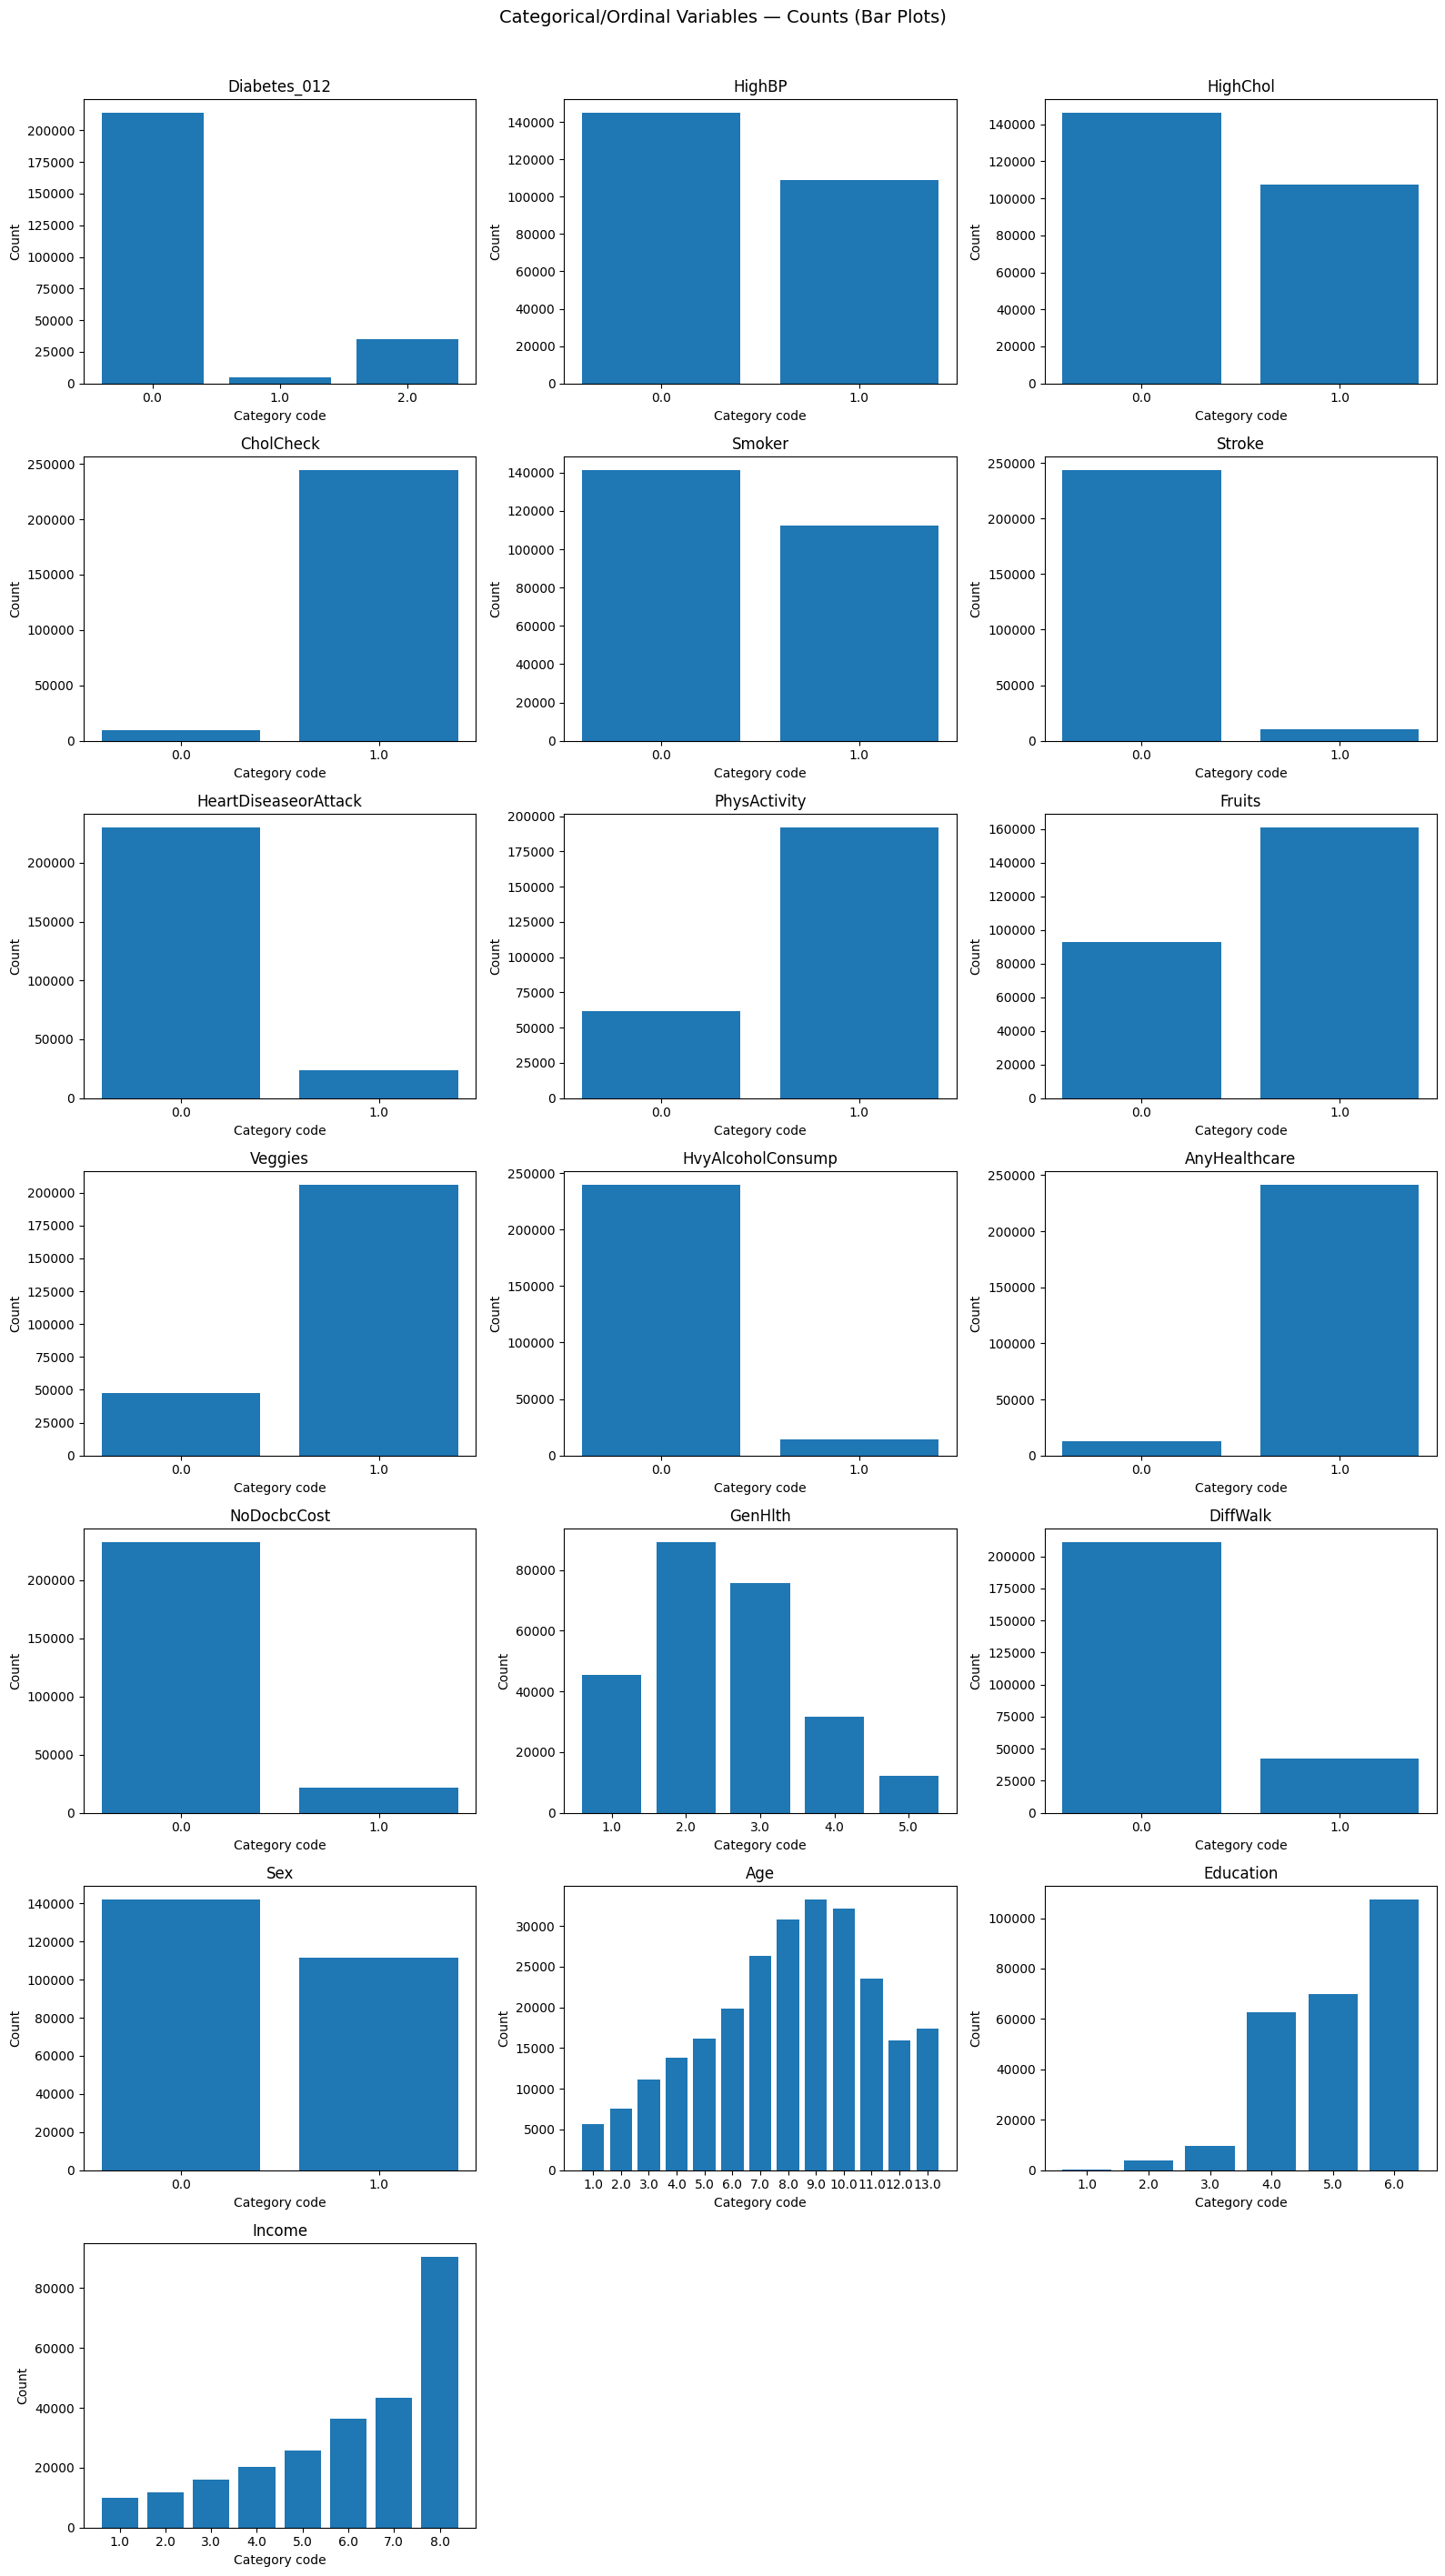

In [29]:
def bar_counts(col, ax):
    counts = df_cdc_diabetes[col].value_counts(dropna=False).sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(col)
    ax.set_xlabel("Category code")
    ax.set_ylabel("Count")

n = len(categorical_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    bar_counts(col, axes[i])

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Categorical/Ordinal Variables — Counts (Bar Plots)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation**

- **Diabetes_012**: most are 0 (no diabetes), fewer in 2 (diabetes), very few in 1 (prediabetes)

- **AnyHealthcare**: strongly concentrated at 1 (most have healthcare)

- **Stroke**, **HeartDiseaseorAttack**: rare events (mostly 0)

- **Age** and **Income** show strong category distributions (not “normal” because they are coded categories)

#### *6- Histograms & variants (KDE, violin) for each continuous feature*

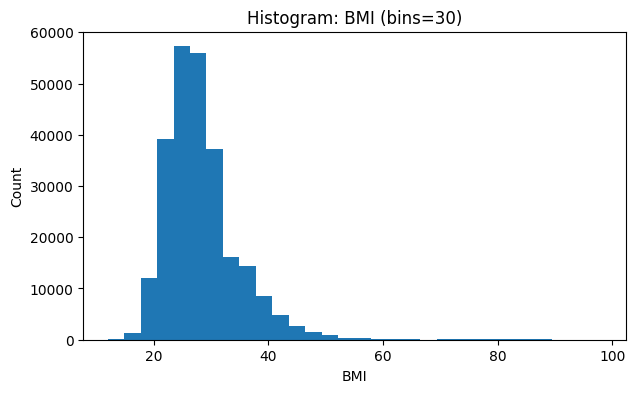

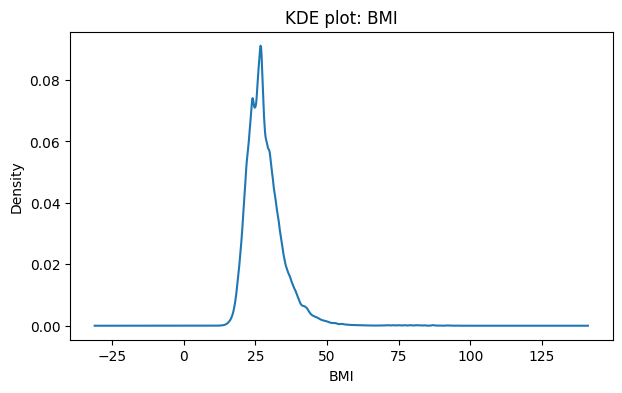

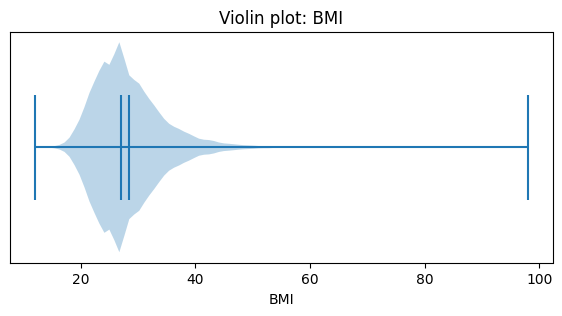

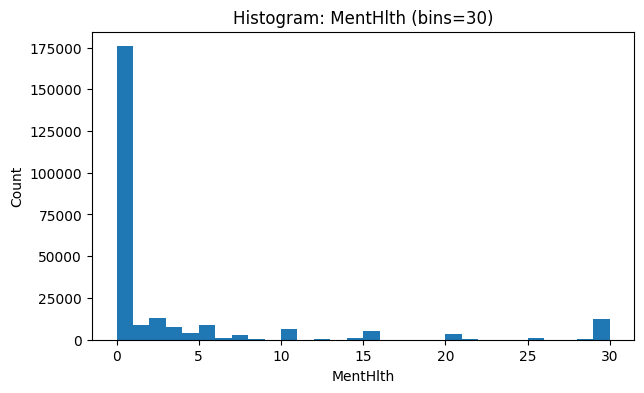

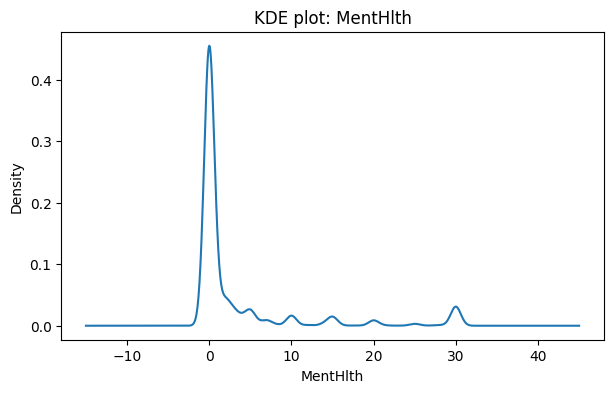

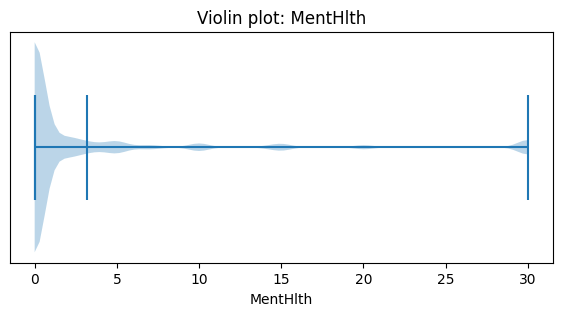

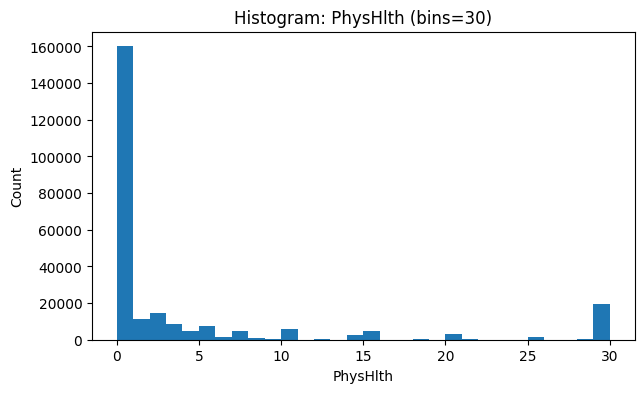

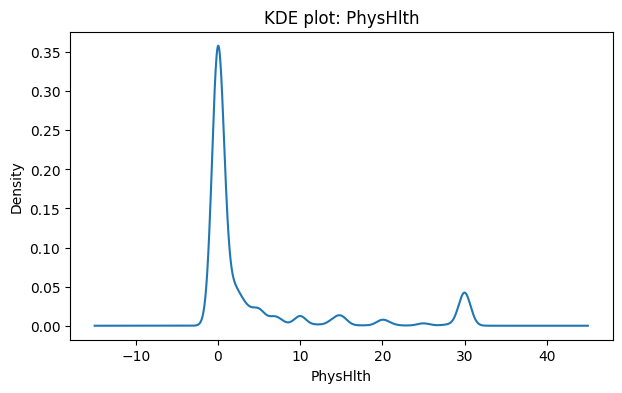

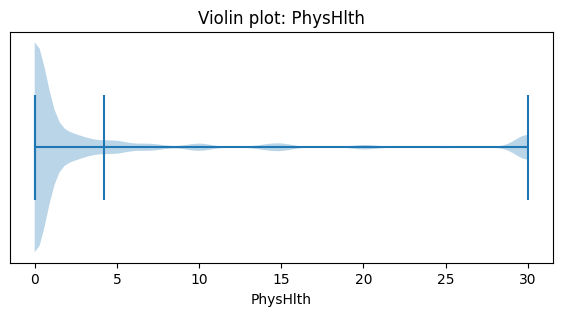

In [32]:
def plot_hist_kde_violin(col, bins=30):
    s = df_cdc_diabetes[col].dropna()

    # Histogram
    fig, ax = plt.subplots(figsize=(7,4))
    ax.hist(s.values, bins=bins)
    ax.set_title(f"Histogram: {col} (bins={bins})")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.show()

    # KDE
    fig, ax = plt.subplots(figsize=(7,4))
    s.plot(kind="kde", ax=ax)
    ax.set_title(f"KDE plot: {col}")
    ax.set_xlabel(col)
    plt.show()

    # Violin
    fig, ax = plt.subplots(figsize=(7,3))
    ax.violinplot(s.values, vert=False, showmeans=True, showmedians=True)
    ax.set_title(f"Violin plot: {col}")
    ax.set_xlabel(col)
    ax.set_yticks([])
    plt.show()

for c in ["BMI", "MentHlth", "PhysHlth"]:
    plot_hist_kde_violin(c, bins=30)

**Interpretation**

- **BMI**: unimodal, **right-skewed** (long right tail), not normal

- **MentHlth / PhysHlth**: extremely high spike at 0 (zero-inflation), then right tail up to 30


#### *7- Swarm plot variant: jittered scatter*

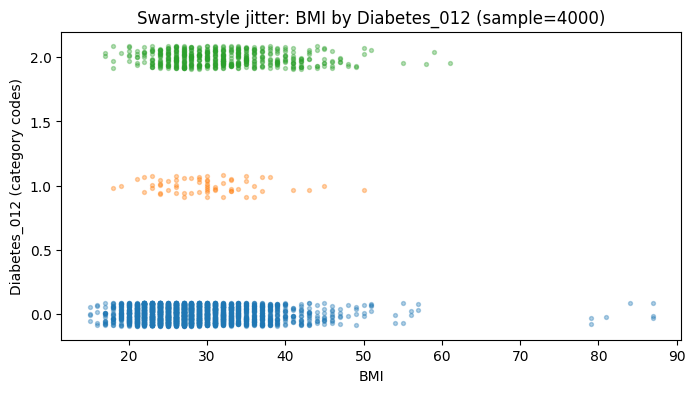

In [33]:
np.random.seed(0)

def jitter_swarm(feature, group, n_sample=4000, jitter=0.18):
    tmp = df_cdc_diabetes[[feature, group]].dropna().sample(n=min(n_sample, len(df_cdc_diabetes)), random_state=0)
    groups = sorted(tmp[group].unique())

    fig, ax = plt.subplots(figsize=(8,4))
    for g in groups:
        vals = tmp.loc[tmp[group]==g, feature].values
        y = np.full(len(vals), float(g))
        y = y + (np.random.rand(len(vals)) - 0.5) * jitter
        ax.scatter(vals, y, s=8, alpha=0.35)

    ax.set_title(f"Swarm-style jitter: {feature} by {group} (sample={len(tmp)})")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"{group} (category codes)")
    plt.show()

# BMI by Diabetes_012
jitter_swarm("BMI", "Diabetes_012")

**Interpretation**

- The diabetes group (2) appears shifted toward higher BMI, with a heavier right tail.


#### *8- Grouped Histograms*

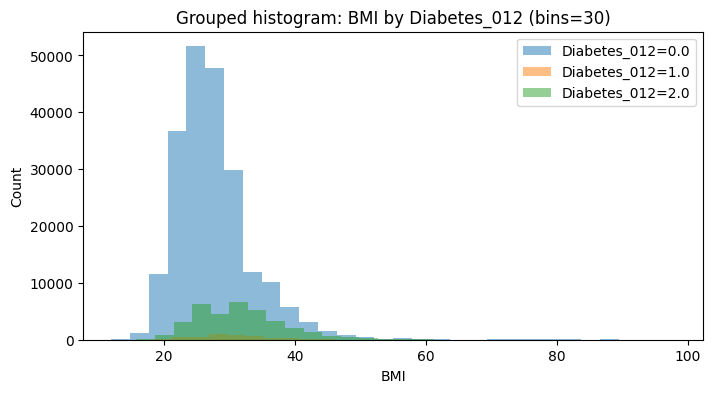

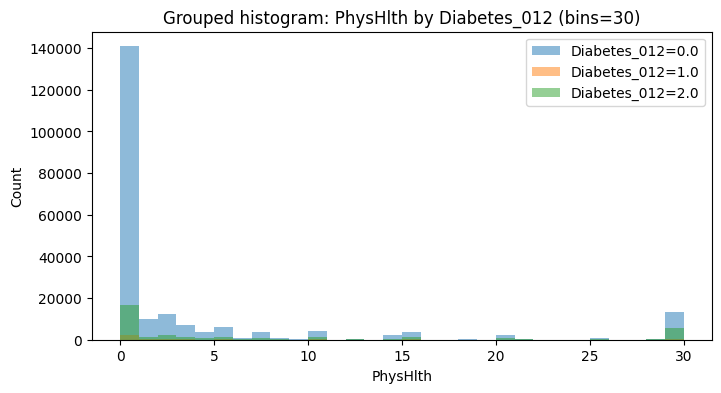

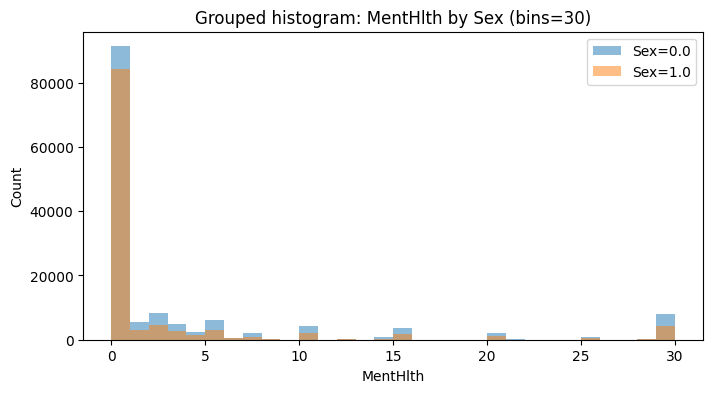

In [34]:
def grouped_hist(feature, group, bins=30):
    fig, ax = plt.subplots(figsize=(8,4))
    for g, sub in df_cdc_diabetes.groupby(group):
        ax.hist(sub[feature].dropna().values, bins=bins, alpha=0.5, label=f"{group}={g}")
    ax.set_title(f"Grouped histogram: {feature} by {group} (bins={bins})")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend()
    plt.show()

grouped_hist("BMI", "Diabetes_012", bins=30)
grouped_hist("PhysHlth", "Diabetes_012", bins=30)
grouped_hist("MentHlth", "Sex", bins=30)

**Interpretation**

- BMI tends to shift upward as diabetes status moves from 0 → 2

- PhysHlth shows higher unhealthy-day counts for diabetes group

- MentHlth differs somewhat by sex but with large overlap

#### *9- Bin size effect*

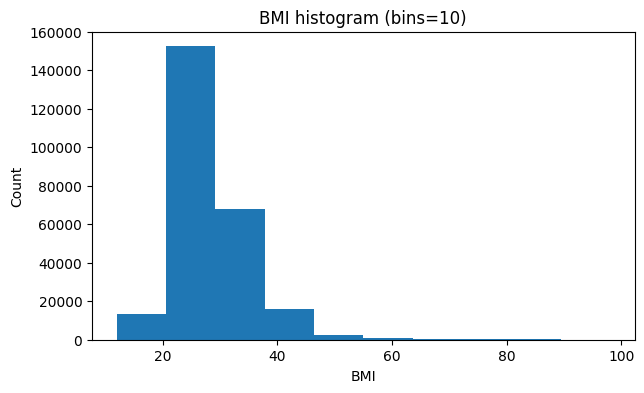

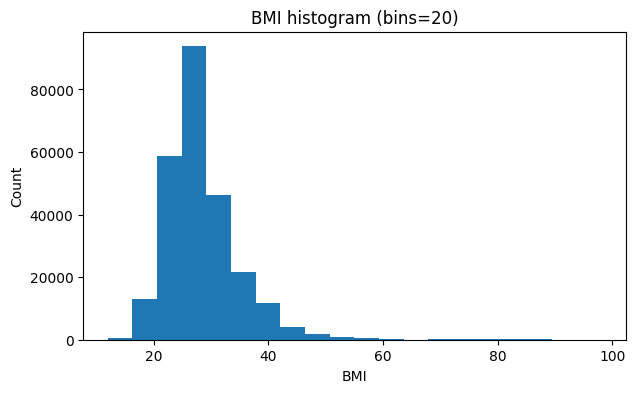

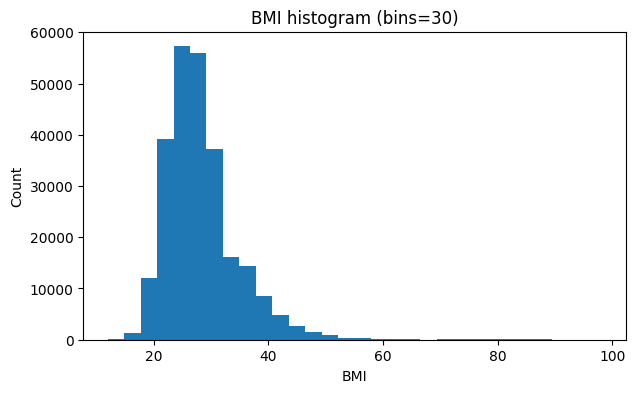

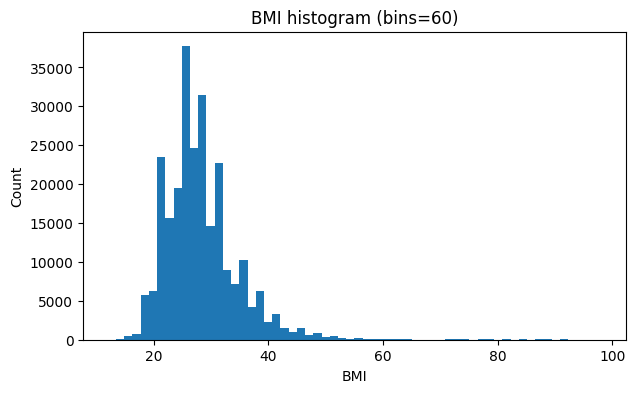

In [35]:
for bins in [10, 20, 30, 60]:
    fig, ax = plt.subplots(figsize=(7,4))
    ax.hist(df_cdc_diabetes["BMI"].dropna().values, bins=bins)
    ax.set_title(f"BMI histogram (bins={bins})")
    ax.set_xlabel("BMI")
    ax.set_ylabel("Count")
    plt.show()

**Interpretation**

- Small bins (10) hide detail (over-smoothing)

- Large bins (60) show more structure but can emphasize noise

- 20 – 40 bins is often a good balance for BMI here

#### *10- Outliers*

In [36]:
def iqr_outliers(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    out = s[(s < lo) | (s > hi)]
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_bound": lo, "upper_bound": hi,
        "n_outliers": int(out.shape[0]),
        "outlier_%": float(out.shape[0] / s.shape[0] * 100),
        "min": float(s.min()),
        "max": float(s.max())
    })

outlier_report = pd.DataFrame({c: iqr_outliers(df_cdc_diabetes[c]) for c in ["BMI","MentHlth","PhysHlth"]}).T
display(outlier_report)

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_%,min,max
BMI,24.0,31.0,7.0,13.5,41.5,9847.0,3.881662,12.0,98.0
MentHlth,0.0,2.0,2.0,-3.0,5.0,36208.0,14.273100,0.0,30.0
PhysHlth,0.0,3.0,3.0,-4.5,7.5,40949.0,16.141990,0.0,30.0


**Interpretation**

- BMI outliers above 41.5 exist, BUT it may be valid & worth sanity checks 

- MentHlth/PhysHlth outliers are partly an artifact of being bounded at 30 with heavy mass at 0 (still valid values)

#### *11- Final Conclusions (Dataset 1: CDC Diabetes Health Indicators)*

- It is a **Usable dataset**: no missing values and consistent with survey-coded indicators.

- **Distribution shape**

    - **BMI**: unimodal, right-skewed, not normal

    - **MentHlth/PhysHlth**: zero-inflated with right-skew (not normal)

    - **Most other variables** are binary/ordinal codes, so “normality” is not expected.

- **Outliers**

    - **BMI** has a small fraction of high values (could be real)

    - **MentHlth/PhysHlth** have many high-day values and they are meaningful outcomes (0–30 day scale).

- **Group shifts**

    - **BMI** and **PhysHlth** distributions generally shift worse/higher for diabetes group.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.